# Tutorial: SECTOR on large-scale high-resolution spatial transcriptomics data

This notebook demonstrates how to run SECTOR on representative modern large-scale high-resolution spatial transcriptomics (ST) datasets used in the manuscript:

| Dataset | Example setting in this tutorial | Original/annotation source | Processed data used for benchmarking |
|---|---|---|---|
| Visium HD CRC | `16 μm` binned output of sample P2 CRC | Raw 10x Genomics Visium HD CRC data: https://www.10xgenomics.com/platforms/visium/product-family/dataset-human-crc; 8- and 16-μm annotations from the SACCELERATOR repository: https://zenodo.org/records/11402686 | Processed `.h5ad` data for 16-μm bins: https://figshare.com/account/articles/32029830?file=63773970 |
| Xenium IDC | `cell-level` IDC representation | Xenium FFPE Human Breast with Custom Add-on Panel dataset curated by Bhuva et al. (2024): https://zenodo.org/records/10516814 | Processed cell-level `.h5ad` data: https://figshare.com/account/articles/32029830?file=63773967 |

The same workflow can be adapted to custom large-scale high-resolution ST datasets: prepare an `.h5ad` file, specify the dataset path and key parameters, train SECTOR, infer spatial domains and pseudotime, and optionally evaluate the results when annotations are available.

Compared with the standard benchmark datasets, these examples contain hundreds of thousands of spatial locations. SECTOR therefore uses its **scale-aware sparse implementation** in `large_scale_mode="auto"` to avoid dense `N × N` graph storage while preserving the same SE, TV and optional balance objectives described in the manuscript.

Guidance on adapting this notebook to custom large-scale high-resolution ST datasets and diagnosing common failure modes is provided at the end of the notebook.


## Example 1: Visium HD CRC (16 μm binned output)

This example uses a 10x Visium HD colorectal cancer (CRC) section at 16 μm bin resolution. The annotation column is `Region`, containing expert-derived tissue-region labels such as neoplasm, connective tissue and non-neoplastic epithelium. SECTOR is run in evaluation mode so that NMI, HOM and COM can be reported after prediction. These annotations are used only for evaluation and are not used during model training.


### 1. Load the SECTOR package


In [1]:
from sector import SECTOR

### 2. Check the expected input format

SECTOR takes an `.h5ad` file that can be loaded as an `AnnData` object. For a custom dataset, the object should contain:

- `adata.X`: expression matrix, preferably raw counts or count-like values; dense and sparse matrices are both supported.
- `adata.obsm["spatial"]`: two-dimensional spatial coordinates with shape `n_obs × 2`.
- Optional `adata.obs[label_key]`: ground-truth annotation used only for evaluation when `eval_mode=1`.

Below, we inspect the Visium HD CRC input object used in this tutorial.


In [2]:
import scanpy as sc

input_adata = sc.read_h5ad('./data/visium_hd/Visium_HD_CRC_016um.h5ad')
input_adata

AnnData object with n_obs × n_vars = 137048 × 18085
    obs: 'barcode', 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'x', 'y', 'imagecol', 'imagerow', 'slices', 'Region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'counts'

`adata.X` should contain the expression matrix. During training, SECTOR performs its own preprocessing, including low-expression gene filtering (`min_cells=5` by default), total-count normalisation (`target_sum=1e4` by default), HVG selection (`n_top_genes=2000` by default unless overridden), and PCA (`n_comps=20` by default unless overridden).

For large-panel or whole-transcriptome datasets such as Visium HD, tuning `n_top_genes` and `n_comps` can be useful because they control the transcriptomic representation used to construct the feature graph.


In [3]:
input_adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 174718336 stored elements and shape (137048, 18085)>

The input object should also contain spatial coordinates in `adata.obsm["spatial"]`. These coordinates are used to construct the spatial neighbourhood graph.


In [4]:
input_adata.obsm['spatial']

array([[45434.83157564, 19379.24976371],
       [62050.15431063, 22051.92742295],
       [64033.98152308, 13137.74503346],
       ...,
       [50856.70251849, 20210.10488319],
       [51906.54071701, 20340.77183774],
       [59930.71332787, 14194.15263544]], shape=(137048, 2))

If annotations are available, they can be stored in `adata.obs`. In this Visium HD CRC example, the annotation column is `Region`. SECTOR is label-free: this column is used only when `eval_mode=1` to compute evaluation metrics.


In [5]:
input_adata.obs['Region']

s_016um_00052_00082-1                Smooth Muscle
s_016um_00010_00367-1                     Neoplasm
s_016um_00163_00399-1                     Neoplasm
s_016um_00238_00388-1                     Neoplasm
s_016um_00144_00175-1            Connective Tissue
                                   ...            
s_016um_00375_00231-1                     Neoplasm
s_016um_00109_00223-1                Smooth Muscle
s_016um_00039_00175-1            Connective Tissue
s_016um_00037_00193-1            Connective Tissue
s_016um_00144_00329-1    Non-neoplastic Epithelium
Name: Region, Length: 137048, dtype: category
Categories (6, object): ['Connective Tissue', 'Neoplasm', 'Non-neoplastic Epithelium', 'Smooth Muscle', 'Veins', 'Vessel']

This Visium HD CRC section is highly imbalanced. For example, the smallest annotated region, `Veins`, contains fewer than 1,000 bins out of 137,048 spatial locations. This imbalance is important when interpreting cluster usage and balance regularisation below.


In [6]:
input_adata.obs['Region'].value_counts()

Region
Neoplasm                     79565
Connective Tissue            26121
Non-neoplastic Epithelium    16363
Smooth Muscle                13033
Vessel                        1044
Veins                          922
Name: count, dtype: int64

### 3. Initialise a SECTOR model


SECTOR loads data using the path convention:

```text
dataset_path / dataset / slice.h5ad
```

This structure is convenient when a project contains multiple datasets or multiple slices per dataset.

Key dataset and evaluation parameters:

- `dataset_path`: root directory containing the ST datasets.
- `dataset`: dataset folder name.
- `slice`: file name without the `.h5ad` suffix.
- `num_clusters`: expected number of spatial domains.
- `eval_mode`: set to `1` when annotations are available and evaluation metrics should be reported; set to `0` for unannotated custom datasets.
- `label`: annotation column in `adata.obs`, required only when `eval_mode=1`.

Key graph and feature parameters:

- `n_top_genes`: number of HVGs used for feature construction ($N_{HVG}$ in the manuscript), default `2000`. This is especially important for large-panel or whole-transcriptome datasets.
- `n_comps`: number of PCA components used as input features ($d$ in the manuscript), default `20`.
- `k`: number of neighbours for feature-graph construction ($k_{feat}$ in the manuscript), default `1`.
- `k_s`: number of neighbours for spatial-graph construction, default `6`. Consider increasing this parameter, for example to `k_s=12`, for half-million-scale or larger datasets such as the Visium HD CRC 8 μm binned output or Xenium IDC cell-level data.

Large-scale parameters:

- `large_scale_mode="auto"` is the recommended default. SECTOR automatically switches to sparse graph construction for large datasets.
- `large_scale_n_obs_threshold=100000` is the default threshold above which SECTOR uses the very-large sparse mode.
- In sparse mode, spatial and feature graphs are stored as sparse nearest-neighbour graphs, substantially reducing memory usage.


In [7]:
m = SECTOR(
    # input slice path
    dataset_path='./data',           # Root directory for ST datasets.
    dataset='visium_hd',             # Visium HD CRC dataset folder.
    slice='Visium_HD_CRC_016um',     # Slice file name without the .h5ad suffix.

    # evaluation and output
    num_clusters=6,                  # Expected number of spatial domains.
    eval_mode=1,                     # Evaluation mode; annotations are used only for metric calculation.
    label='Region',                  # Ground-truth annotation column in adata.obs, required when eval_mode=1.

    # key graph and feature parameters
    n_comps=20,                      # Number of PCA components (d in the manuscript).
    n_top_genes=2000,                # Number of HVGs.
    k=1,                             # Feature-graph neighbours (k_feat in the manuscript).
    k_s=6,                           # Spatial-graph neighbours.

    # large-scale mode
    large_scale_mode='auto',         # Automatically use sparse graph construction for large datasets.
)


Device: cuda:0
[Preprocess] Using HVG features (n_top_genes=2000, mode=large/sparse)
Dataset Name: visium_hd
Number of nodes: 137048
Number of edges: 481742
Number of features: 20
Number of classes: 6 (labels loaded: True)
Feature: torch.Size([137048, 20])
edge_index: torch.Size([2, 963484])


When the dataset is large, SECTOR automatically switches to the sparse large-scale implementation, as indicated by the large/sparse mode message above. This mode preserves the same SECTOR objective, but constructs spatial and feature graphs as sparse nearest-neighbour graphs to avoid dense `N × N` distance or adjacency matrices. See Supplementary Section S3.5 of the manuscript for implementation details.


### 4. Train the SECTOR model

Important training parameters:

- `lambda_tv`: spatial total-variation (TV) coefficient. Larger values enforce stronger spatial smoothness; smaller values preserve sharper local boundaries. We use `lambda_tv=4.0` for the large-scale examples in this notebook; reduce it if domains appear oversmoothed.
- `lr`: learning rate for Adam optimisation. Large-scale datasets may require additional tuning of `lr`; the two examples in this notebook use different learning rates.
- `stability_nmi_thr`: label-free early-stopping threshold based on assignment stability between epochs. Setting this to `1.0` uses final-epoch mode, which is often more practical for very large datasets because it avoids frequent early-stopping checks.
- `balance_probe_epochs`: number of initial probe epochs used to detect severe under-use of clusters.
- `gamma_balance`: balance-regularisation weight, activated only if the balance probe detects cluster under-use. For sequencing-based ST data, `gamma_balance=1.0` is a useful starting point; for imaging-based single-cell data, smaller values such as `0.1` are often sufficient.

Practical tuning rule: increase `lambda_tv` or graph connectivity if domains are fragmented; reduce `lambda_tv` or graph connectivity if domains are oversmoothed. If optimisation is unstable or very slow on a large dataset, tune `lr` before changing many other parameters.


In [8]:
m.fit(
    lambda_tv=4.0,           # Spatial TV regularisation coefficient.
    lr=0.0001,               # Learning rate; a smaller value is used here for the large Visium HD graph.
    stability_nmi_thr=1.0,   # Fixed-horizon / final-epoch mode for large-scale training.
    balance_probe_epochs=20, # Number of balance-probe epochs.
    gamma_balance=1.0,       # Balance weight; used only if the probe detects cluster under-use.
)


[Probe] Starting 20 epochs with balance OFF...
[Probe] Epoch 0 | Loss=13.346949 | UsedK=6/6
[Probe] Epoch 19 | Loss=13.379622 | UsedK=6/6
[Continue] K stable at end of probe. Continuing with balance OFF.
Epoch: 20 [0.245s], Loss: 13.381761, NMI: 0.292124, HOM: 0.343410, COM: 0.254167, K: 6/6, 
Epoch: 21 [0.256s], Loss: 13.383937, NMI: 0.293948, HOM: 0.345897, COM: 0.255566, K: 6/6, 
Epoch: 22 [0.211s], Loss: 13.386147, NMI: 0.295773, HOM: 0.348351, COM: 0.256985, K: 6/6, 
Epoch: 23 [0.255s], Loss: 13.388393, NMI: 0.297525, HOM: 0.350720, COM: 0.258342, K: 6/6, 
Epoch: 24 [0.253s], Loss: 13.390667, NMI: 0.299324, HOM: 0.353106, COM: 0.259759, K: 6/6, 
Epoch: 25 [0.214s], Loss: 13.392973, NMI: 0.300819, HOM: 0.355133, COM: 0.260914, K: 6/6, 
Epoch: 26 [0.255s], Loss: 13.395309, NMI: 0.302715, HOM: 0.357626, COM: 0.262422, K: 6/6, 
Epoch: 27 [0.212s], Loss: 13.397673, NMI: 0.304297, HOM: 0.359718, COM: 0.263674, K: 6/6, 
Epoch: 28 [0.253s], Loss: 13.400064, NMI: 0.305939, HOM: 0.361849, C

### 5. Infer and visualise spatial domains and pseudotime

Prediction-related parameters:

- `spatial_anchor`: orients the inferred pseudotime using a broad spatial direction, such as `"south"` or `"north"`.
- `root_cluster`: alternatively, users can manually orient pseudotime by specifying a predicted cluster as the starting point after inspecting the spatial domains.
- `plot`: if `True`, spatial-domain and pseudotime plots are generated and saved.
- `island_min_frac` and `island_min_abs`: optional post hoc island-cleaning parameters that reduce small disconnected fragments. For large high-resolution data, use these parameters cautiously because very small but biologically meaningful regions may exist. Here, we use the same moderate cleaning values as in the 10x Visium example.

For custom datasets, inspect the predicted domains first, then adjust `spatial_anchor`, `root_cluster` and island-cleaning settings if needed.


[Post hoc] Island cleaner changed 12802 spots (min_abs=40, min_frac=0.1, max_iter=2)
[Final metrics] NMI=0.699089, HOM=0.731658, COM=0.669296, (K=5/6)


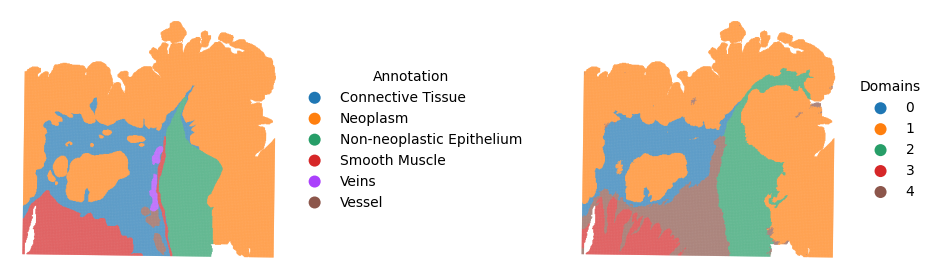

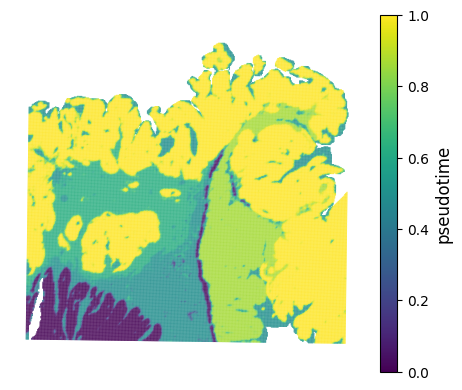

In [9]:
adata = m.pred(
    spatial_anchor='south',   # Spatial orientation of pseudotime; root_cluster can be used after inspecting domains.
    plot=True,                # If True, spatial domains and pseudotime are plotted and saved.
    island_min_frac=0.1,      # Optional: minimum relative component size for island cleaning.
    island_min_abs=40,        # Optional: absolute minimum component size for island cleaning.
)


In this Visium HD example, the balance probe can initially pass, indicating that the expected number of clusters is used during the probe phase. Later in training, however, one cluster may become under-used, so the final prediction may contain fewer occupied clusters than `num_clusters`.

This behaviour can occur in highly imbalanced datasets such as Visium HD CRC, where very small annotated structures occupy only a tiny fraction of all spatial locations. The SE + TV objective favours low-entropy, spatially coherent partitions and does not force equal cluster occupancy unless the balance prior is strong enough. In practice, users can respond in two ways:

1. **If the under-used cluster corresponds to an expected biological region that should be recovered**, increase `balance_probe_epochs`, increase `gamma_balance` modestly, or reconsider `num_clusters`.
2. **If forcing all clusters creates artificial equal-sized regions or harms spatial coherence**, keep the weaker balance setting and interpret the result as a lower-occupancy structure under the chosen objective.

Thus, balance parameters should be treated as safeguards against severe cluster under-use, not as routine constraints that force all domains to be equally sized.


### 6. Inspect evaluation metrics


When `eval_mode=1`, final clustering metrics are stored in `adata.uns["SECTOR"]["final_metrics"]`. These include NMI, HOM and COM, which are the main clustering metrics reported in the manuscript.


In [10]:
print('NMI:', adata.uns['SECTOR']['final_metrics']['NMI'])
print('HOM:', adata.uns['SECTOR']['final_metrics']['HOM'])
print('COM:', adata.uns['SECTOR']['final_metrics']['COM'])

NMI: 0.6990887376739733
HOM: 0.7316578161752819
COM: 0.6692956537936686


## Example 2: Xenium IDC (cell-level resolution)

This example uses the cell-level representation of a 10x Xenium breast IDC section. Xenium data are high-resolution and targeted-panel based: they contain many cells but fewer genes than whole-transcriptome sequencing-based ST. The annotation column is again `Region`, and annotations are used only when `eval_mode=1` for metric reporting.


SECTOR is label-free. Enabling `eval_mode` (`eval_mode=1`) reports evaluation metrics after prediction, but does not introduce label information during training.

Compared with the Visium HD example, this Xenium example uses a smaller balance weight (`gamma_balance=0.1`), a larger learning rate (`lr=0.01`) and a larger spatial neighbourhood (`k_s=12`). In practice, large-scale targeted-panel datasets may require different optimisation and graph settings from large whole-transcriptome datasets.


In [11]:
m = SECTOR(
    # input slice path
    dataset_path='./data',       # Root directory for ST datasets.
    dataset='xenium',            # Xenium breast IDC dataset folder.
    slice='Xenium_IDC_cell',     # Cell-level Xenium slice file name without the .h5ad suffix.

    # evaluation and output
    label='Region',              # Ground-truth annotation column in adata.obs, required when eval_mode=1.
    num_clusters=8,              # Expected number of spatial domains.
    eval_mode=1,                 # Evaluation mode; annotations are used only for metric calculation.

    # graph parameters
    k_s=12,                      # Larger spatial neighbourhood for cell-level granularity.
    large_scale_mode='auto',     # Automatically use sparse graph construction for large datasets.
)


Device: cuda:0
[Preprocess] Using HVG features (n_top_genes=2000, mode=large/sparse)
Dataset Name: xenium
Number of nodes: 573091
Number of edges: 4147491
Number of features: 20
Number of classes: 8 (labels loaded: True)
Feature: torch.Size([573091, 20])
edge_index: torch.Size([2, 8294983])


### Train the SECTOR model


In [12]:
m.fit(
    lambda_tv=4.0,           # Spatial TV regularisation coefficient.
    lr=0.01,                 # Learning rate; tuned for this Xenium cell-level example.
    stability_nmi_thr=1.0,   # Fixed-horizon / final-epoch mode for large-scale training.
    balance_probe_epochs=20, # Number of balance-probe epochs.
    gamma_balance=0.1,       # Smaller balance weight often works better for imaging-based cell-level data.
)


[Probe] Starting 20 epochs with balance OFF...
[Probe] Epoch 0 | Loss=16.897585 | UsedK=8/8
[Probe] Epoch 19 | Loss=15.698036 | UsedK=8/8
[Continue] K stable at end of probe. Continuing with balance OFF.
Epoch: 20 [1.134s], Loss: 15.670196, NMI: 0.263616, HOM: 0.360264, COM: 0.207855, K: 8/8, 
Epoch: 21 [1.117s], Loss: 15.646505, NMI: 0.266285, HOM: 0.364642, COM: 0.209717, K: 8/8, 
Epoch: 22 [1.261s], Loss: 15.628639, NMI: 0.268964, HOM: 0.368442, COM: 0.211783, K: 8/8, 
Epoch: 23 [1.109s], Loss: 15.617218, NMI: 0.271752, HOM: 0.371640, COM: 0.214184, K: 8/8, 
Epoch: 24 [1.133s], Loss: 15.611856, NMI: 0.274157, HOM: 0.373810, COM: 0.216453, K: 8/8, 
Epoch: 25 [1.141s], Loss: 15.609637, NMI: 0.275858, HOM: 0.374964, COM: 0.218189, K: 8/8, 
Epoch: 26 [1.157s], Loss: 15.607306, NMI: 0.277137, HOM: 0.375919, COM: 0.219466, K: 8/8, 
Epoch: 27 [1.132s], Loss: 15.603547, NMI: 0.277801, HOM: 0.376602, COM: 0.220067, K: 8/8, 
Epoch: 28 [1.067s], Loss: 15.599150, NMI: 0.278193, HOM: 0.377208, C

### Infer and visualise spatial domains and pseudotime


[Post hoc] Island cleaner changed 71578 spots (min_abs=20, min_frac=0.03, max_iter=2)
[Final metrics] NMI=0.390958, HOM=0.470726, COM=0.334307, (K=7/8)


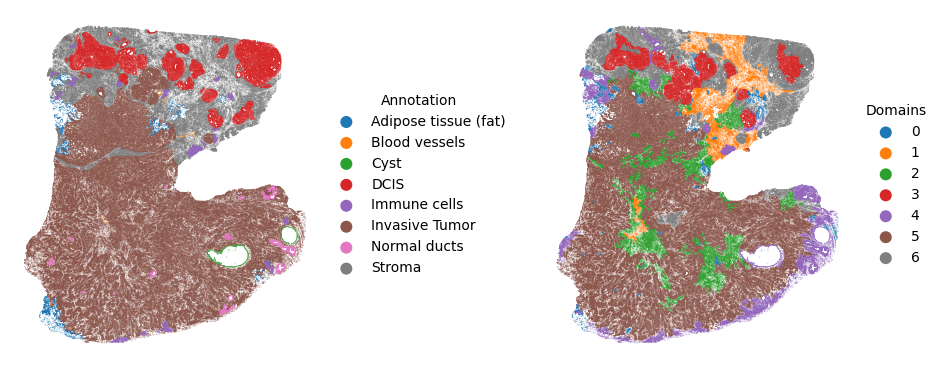

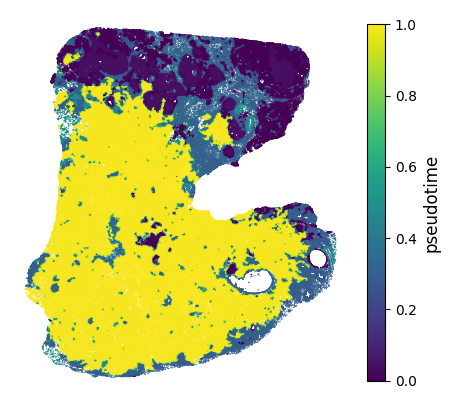

In [13]:
adata = m.pred(
    spatial_anchor='south',  # Spatial orientation of pseudotime; root_cluster can be used after inspecting domains.
    island_min_frac=0.03,    # Optional: minimum relative component size for island cleaning.
    island_min_abs=20,       # Optional: absolute minimum component size for island cleaning.
    plot=True,               # If True, spatial domains and pseudotime are plotted and saved.
    invert_y=False           # Set True if the platform-specific coordinate convention requires vertical flipping.
)


### Evaluation metrics


In [14]:
print('NMI:', adata.uns['SECTOR']['final_metrics']['NMI'])
print('HOM:', adata.uns['SECTOR']['final_metrics']['HOM'])
print('COM:', adata.uns['SECTOR']['final_metrics']['COM'])

NMI: 0.3909578769717642
HOM: 0.47072560018406334
COM: 0.3343071994929792


## Adapting this notebook to a custom large-scale high-resolution ST dataset

For a new dataset, use the following checklist:

1. Save the data as an `.h5ad` file under `dataset_path / dataset / slice.h5ad`.
2. Ensure that `adata.X` contains the expression matrix and `adata.obsm["spatial"]` contains two-dimensional spatial coordinates.
3. If ground-truth annotations are available, store them in `adata.obs` and set `eval_mode=1` with the corresponding `label`; otherwise set `eval_mode=0`.
4. Set `num_clusters` to the expected number of spatial domains. If strong cluster under-use persists despite balance tuning, reconsider whether the requested number of domains is supported by the data.
5. Keep `large_scale_mode="auto"` for high-resolution datasets so SECTOR can switch to sparse graph construction when needed.
6. Tune the most important graph and feature parameters:
   - Increase `lambda_tv` if domains are fragmented or noisy.
   - Decrease `lambda_tv` if neighbouring biological regions are oversmoothed.
   - Tune `k` (`k_feat` in the manuscript) and `k_s` if the feature or spatial graph appears too sparse or too connected.
   - For whole-transcriptome datasets, tune `n_top_genes` and `n_comps`; for small targeted panels, retaining most informative genes is often preferable.
7. Tune optimisation parameters for large datasets:
   - `lr` can be dataset-dependent. In this tutorial, the Visium HD CRC 16 μm example uses `lr=0.0001`, whereas the Xenium IDC cell-level example uses `lr=0.01`.
   - For very large datasets, `stability_nmi_thr=1.0` uses final-epoch mode and avoids frequent early-stopping checks.
8. Keep the balance probe enabled. If severe cluster under-use occurs, increase `balance_probe_epochs`, modestly increase `gamma_balance`, or reconsider `num_clusters`. If the inferred domains become unnaturally equal-sized, reduce `gamma_balance`.


## Diagnostics on common failure modes

SECTOR is generally robust across moderate parameter ranges, but different tissues and spatial technologies may require limited tuning. Use the patterns below to diagnose common issues and choose targeted adjustments.

### 1. Oversmoothed domains

**Typical pattern:** neighbouring anatomical regions are merged, narrow boundaries disappear, or small biologically meaningful domains are absorbed into larger regions.

Possible adjustments:

- Decrease `lambda_tv` to reduce spatial smoothing.
- Reduce spatial or feature-graph connectivity by decreasing `k_s` and/or `k`.
- Reduce post hoc island-cleaning strength by decreasing `island_min_frac` and/or `island_min_abs`.

### 2. Fragmented or noisy domains

**Typical pattern:** predicted domains contain many isolated islands, boundaries are noisy, or spatially coherent tissue regions are split into many small pieces.

Possible adjustments:

- Increase `lambda_tv` to encourage spatial coherence.
- Increase spatial or feature-graph connectivity by increasing `k_s` and/or `k`.
- Apply modest island cleaning by slightly increasing `island_min_frac` and/or `island_min_abs`.

### 3. Under-used clusters

**Typical pattern:** the number of occupied predicted clusters is smaller than `num_clusters`, or one or more clusters contain very few spots/cells.

Possible adjustments:

- Keep the balance probe enabled so SECTOR first tests whether all clusters are naturally used with `gamma_balance=0`.
- Increase `gamma_balance` only if cluster under-use persists after the balance probe.
- Reconsider whether `num_clusters` is biologically reasonable; persistent under-use can indicate that the requested number of domains is larger than the tissue structure supports.
- For large or highly heterogeneous datasets, also tune `lr`, because unstable optimisation can contribute to poor cluster usage.

### 4. Unstable training or poor convergence

**Typical pattern:** results vary substantially across runs or slices, cluster usage changes abruptly, or training does not stabilise.

Possible adjustments:

- Reduce `lr` if optimisation appears unstable, especially for large or highly heterogeneous datasets.
- Increase `epochs` if the model has not converged.
- Check whether early stopping is too aggressive for the dataset.
- Keep the random seed fixed when comparing parameter settings.

### 5. High memory usage

**Typical pattern:** graph construction becomes slow, GPU/CPU memory is exhausted, or training becomes impractical.

Possible adjustments:

- Keep `large_scale_mode="auto"`. SECTOR will automatically switch from dense to sparse graph construction for larger datasets.
- For very large datasets, SECTOR further reduces memory usage by constructing the feature graph from the PCA representation rather than repeatedly updating it from a changing neural representation.
- The default `large_scale_n_obs_threshold` is `100000`; users can adjust this threshold according to their hardware.
- For whole-transcriptome or large-panel datasets, reduce `n_top_genes` and/or `n_comps` to lower the memory cost of feature construction.
- Reducing `k_s` and/or `k` can also reduce graph size, but may affect spatial continuity and should be tuned together with `lambda_tv`.
